# Conditional GAN on MNIST

## Overview

We implement and train a **Conditional Generative Adversarial Network (cGAN)** on the **MNIST** dataset. 
The goal of this example is to:

- Understand how **conditioning** changes the behavior of a GAN.
- Compare a **conditional GAN** to a **vanilla GAN**.
- Generate **digit-specific images** using label-guided generation.

We modify the architecture and training loop of the regular GAN to incorporate **class labels** in both the **Generator** and **Discriminator**.


## What is a GAN?

A **Generative Adversarial Network (GAN)** consists of two neural networks:

- **Generator (G):** Takes random noise and generates images.
- **Discriminator (D):** Tries to distinguish real images from generated ones.

They are trained in a **minimax game**:  
- G tries to **fool** D by creating realistic images.  
- D tries to **detect** generated images.  
The competition leads to increasingly better outputs from G.


## What is a Conditional GAN (cGAN)?

A **Conditional GAN** extends the original GAN by **adding auxiliary information** — such as **class labels** — to both the Generator and Discriminator.

- Instead of generating a random image, the Generator learns to produce an image **conditioned on a specific label**.
- The Discriminator receives both the image and its label and learns whether this image **matches the given class** and whether it is real or generated.


## Key Differences: GAN vs cGAN

| Feature           | GAN                                 | cGAN                                               |
|------------------|--------------------------------------|----------------------------------------------------|
| Input to G        | Random noise                        | Noise **+ class label**                            |
| Input to D        | Image                               | Image **+ class label**                            |
| Output of G       | Any plausible image                 | Image that matches the **given class**             |
| Control over output | ❌ No control                      | ✅ Can generate specific digits (e.g., "3", "9")   |



## Dataset

We use the **MNIST** dataset, which consists of 70,000 images of grayscale handwritten digits (0-9) of size **28x28** pixels. 
The images are normalized to the range $[-1,1]$ for stable GAN training.


## Network Architectures: Generator and Discriminator

In this conditional setup, both the **Generator** and **Discriminator** are modified to incorporate **class label information**.


### Generator Architecture

The Generator receives:
- A **random noise vector** of size 100.
- A **label embedding** of size 100 (one for each class).

These are **concatenated channel-wise** and passed through several `ConvTranspose2d` layers to upsample to a $28\times28$ image.

#### Layer-by-layer Description:
1. **Label Embedding**: Embeds the class label into a 100-dim vector.
2. **Concatenation**: Noise and label embedding are concatenated → shape: $[B, 200, 1, 1]$
3. **Transposed Convolutional Layers**:
   - `ConvTranspose2d(200 → 512)`, kernel: 4, stride: 1, padding: 0 → output: $4\times4$
   - `ConvTranspose2d(512 → 256)`, kernel: 3, stride: 2, padding: 1 → output: $7\times7$
   - `ConvTranspose2d(256 → 128)`, kernel: 4, stride: 2, padding: 1 → output: $14\times14$
   - `ConvTranspose2d(128 → 64)`, kernel: 4, stride: 2, padding: 1 → output: $28\times28$
   - `Conv2d(64 → 1)`, kernel: 3, stride: 1, padding: 1 → final grayscale image
4. **Activations**:
   - `ReLU` after each transpose conv
   - `BatchNorm2d` to stabilize training
   - Final `Tanh` to output pixel values in $[-1, 1]$


### Discriminator Architecture

The Discriminator receives:
- A **real or generated image**
- A **label embedding** reshaped to match the image shape $(1, 28, 28)$

These are **concatenated as two channels** and passed through several convolutional layers to classify real vs generated.

#### Layer-by-layer Description:
1. **Label Embedding**: Transforms class label into a 2D image of shape $[1, 28, 28]$
2. **Concatenation**: Image + label → shape: $[2, 28, 28]$
3. **Convolutional Layers**:
   - `Conv2d(2 → 32)`, kernel: 4, stride: 2, padding: 1 → $14\times14$
   - `Conv2d(32 → 64)`, kernel: 4, stride: 2, padding: 1 → $7\times7$
   - `Conv2d(64 → 64)`, kernel: 3, stride: 2, padding: 1 → $4\times4$
4. **Regularization**:
   - `LeakyReLU(0.2)` activations after each conv
   - `BatchNorm2d` for stability
   - `Dropout(0.3)` for regularization
5. **Output**:
   - Flattened and passed through `Linear(64*4*4 → 1)` to output a real/generated score

<font size="2">
Note: We lower the capacity of Discriminator since the version in GAN example does not work well.
</font>

#### 1. Necessary Packages

Import libraries for neural networks, data handling, and plotting.

Utilizes GPU if available for faster training.

In [ ]:
!pip install torchinfo

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchinfo import summary
import matplotlib.pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### 2. Data Preparation

Load the MNIST dataset using `torchvision.datasets.MNIST` and instantiate `train_loader` and `test_loader` via `DataLoader`, which handles batching and shuffling.

Note:

1. `torchvision.transforms.Compose`: Composes several transforms together.

2. `torchvision.transforms.Normalize(mean, std, inplace=False)`:
$$\frac{\text{input} - \text{mean}}{\text{std}}$$
Normalize grayscale images, which are in range [0,1] after `ToTensor`, to the range [-1,1], required for Tanh activation in the Generator. 
It takes `tensor` as input only.

3. Images in MNIST are not shuffled by default, so we set `shuffle=True` for test set to visualize the generated images for different digits easily.


In [3]:
batch_size = 256

# transform images to tensor in range [-1,1]
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])

# Load training and test datasets and their according data loaders
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

#### 3. Image Visualization

Define the function to display multiple images and if labels are given, also append them to the bottom of the corresponding images.

By default, this function will display 10 images per row.

In [4]:
def show_images(images, labels=None, n_cols=10):
    """
    Display a grid of MNIST images (real or generated).

    Args:
        images (Tensor): Tensor of shape (B, 1, 28, 28) representing grayscale images.
        labels (Tensor or list, optional): Labels to display with the images.
        n_cols (int): Number of columns in the image grid.

    Returns:
        None. Displays a matplotlib grid of images.
    """
    # convert images into size B x 28 x 28, independent of their previous shape
    images = images.view(-1, 28, 28).cpu().detach().numpy()
    # convert back to [0,255] range
    images = torch.tensor((images + 1) * 127.5, dtype=torch.uint8)
    n_images = images.shape[0]
    n_rows = math.ceil(n_images / n_cols)

    # generate a figure with the given number of rows and columns
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows * 1.2), squeeze=False)
    axes = axes.flatten()

    # iterate over all axes
    for i, ax in enumerate(axes):
        if i < n_images:
            ax.imshow(images[i], cmap='gray')
            ax.axis('off')

            # print label underneath the text
            if labels is not None and i < len(labels):
                # Convert label to string
                label = str(labels[i].item())
                y_offset = -0.1
                ax.text(0.5, y_offset, label, ha='center', va='center', transform=ax.transAxes, fontsize=12)

    plt.tight_layout()
    plt.show()

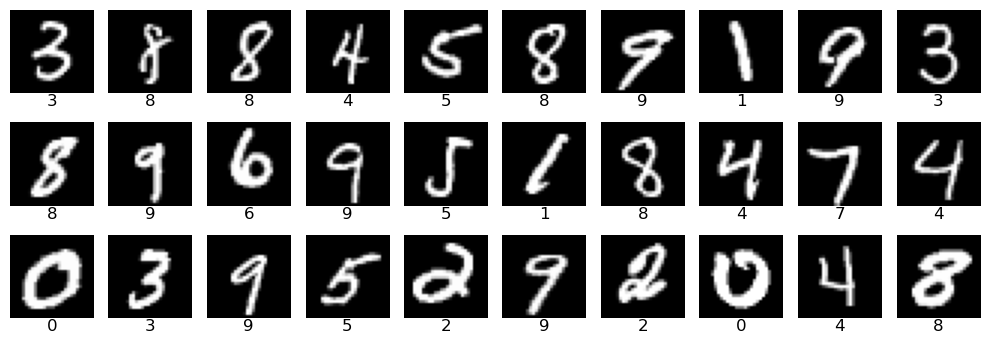

In [5]:
# display the first 30 images in a batch of the training set
one_train_batch, labels = next(iter(train_loader))
show_images(one_train_batch[:30],labels[:30])

#### 4. Define Generator

We define a Generator network to generate MNIST-style digit images from a latent noise vector using transposed convolution layers.
Since the network requires some special handling of the labels, we need to implement it as `torch.nn.Module`. 
However, we make internal use of `torch.nn.Sequential` to build parts of the network.

Before building the network, some important layers:

---

**Transposed Convolution Layer**

```python
torch.nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, output_padding, bias=False)
```
A transposed convolution layer (also known as deconvolution) is used to upsample feature maps. [Documentation](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html)

**Batch Normalization Layer**

```python
torch.nn.BatchNorm2d(num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, device=None, dtype=None)
```
[Documentation](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)

**Embedding Layer**

```python
torch.nn.Embedding(num_classes, embedding_dim)
```
The `Embedding` layer is a lookup table that stores embeddings of a fixed dictionary and size. It is typically used to represent categorical data in the form of dense vectors, which is common in tasks like Natural Language Processing and classification. [Documentation](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)

- **num_classes** (int): The size of the dictionary of embeddings, i.e., the number of unique classes or tokens. This is the number of distinct entries in the embedding table.
- **embedding_dim** (int): The size of each embedding vector. This is the dimensionality of the output space for each entry in the embedding table.

Input:

- A tensor of integers, where each integer represents an index corresponding to a class or token in the embedding table. The shape of the input tensor is `(N,*)`, where `N` is the number of indices, and `*` can be any additional dimensions for batch processing.

Output:
- A tensor of shape `(N, embedding_dim)`, where each input index is replaced by its corresponding embedding vector from the weight matrix. This is a dense vector representation for each class.




In [39]:
class Generator(torch.nn.Module):

    def __init__(self, num_classes=10, embedding_dim=100):
        super(Generator, self).__init__()

        # Embeds class labels into vectors of size 100
        self.label_emb = torch.nn.Embedding(num_classes, embedding_dim)

        # Builds the remainder of the network
        self.model = torch.nn.Sequential(

            torch.nn.ConvTranspose2d(in_channels=100+embedding_dim, out_channels=512, kernel_size=4, stride=1, padding=0, bias=False),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(True),

            torch.nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=3, stride=2, padding=1, bias=False),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(True),

            torch.nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1, bias=False),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(True),

            torch.nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(True),

            torch.nn.Conv2d(64, 1, 3, 1, 1, bias=False),
            torch.nn.Tanh()  # pixel ranges [-1, 1]
        )

    def forward(self, embeddings, labels):
        """
        Generates images from embeddings (noise) and class labels.

        noise (Tensor): Random noise vector of shape [B, 100, 1, 1].
        labels (Tensor): Class labels of shape [B], with values from 0 to 9.

        Returns:
            Tensor: Generated images of shape [B, 1, 28, 28].
        """
        # print(labels.shape)
        # print(labels)
        # if labels.dim() > 1:
        #     labels = labels[0]
        labels = labels.long()
        # print(labels)
        # Embed labels and reshape to match noise shape
        label_embedding = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        # print(label_embedding.shape)
        # print(embeddings.shape)
        # Concatenate noise and label embeddings → (B, 200, 1, 1)
        x = torch.cat((embeddings, label_embedding), dim=1)
        # Push it through the network
        return self.model(x)

In [ ]:
net_G = Generator()
summary(
    net_G,
    input_data=(torch.randn(1, 100, 1, 1), torch.randint(0, 10, (1,))),
    device="cpu"
)


Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 1, 28, 28]            --
├─Embedding: 1-1                         [1, 100]                  1,000
├─Sequential: 1-2                        [1, 1, 28, 28]            --
│    └─ConvTranspose2d: 2-1              [1, 512, 4, 4]            1,638,400
│    └─BatchNorm2d: 2-2                  [1, 512, 4, 4]            1,024
│    └─ReLU: 2-3                         [1, 512, 4, 4]            --
│    └─ConvTranspose2d: 2-4              [1, 256, 7, 7]            1,179,648
│    └─BatchNorm2d: 2-5                  [1, 256, 7, 7]            512
│    └─ReLU: 2-6                         [1, 256, 7, 7]            --
│    └─ConvTranspose2d: 2-7              [1, 128, 14, 14]          524,288
│    └─BatchNorm2d: 2-8                  [1, 128, 14, 14]          256
│    └─ReLU: 2-9                         [1, 128, 14, 14]          --
│    └─ConvTranspose2d: 2-10             [1, 64, 28, 28]  

#### 5. Define Discriminator

We define a convolutional neural network that takes in an MNIST image, concatenates them with a channel containing the label embedding, and outputs a score indicating whether the image is real or generated.

An alternative would be to define a Discriminator with two heads, one with a binary output classifying real and generated images, and one categorical output that outputs one logit for each target class, which can then be classified via `CrossEntropy` loss.

In [42]:
class Discriminator(torch.nn.Module):
    def __init__(self, num_classes=10, img_size=28):
        super(Discriminator, self).__init__()

        # Embeds class labels into image-sized vectors
        self.label_emb = torch.nn.Embedding(num_classes, img_size * img_size)

        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=2, out_channels=32, kernel_size=4, stride=2, padding=1),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Dropout(0.3),

            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Dropout(0.3),

            torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.LeakyReLU(0.2),
            torch.nn.Dropout(0.3),

            torch.nn.Flatten(),
            torch.nn.Linear(64 * 4 * 4, 1)  # Output: (B, 1) logit (real/generated)
        )

    def forward(self, images, labels):
        """
        Discriminates real or generated images conditioned on labels.

        Args:
            images (Tensor): Input image tensor of shape [B, 1, 28, 28].
            labels (Tensor): Class labels of shape [B], with values from 0 to 9.

        Returns:
            Tensor: Logits of shape [B, 1], where higher means more "real".
        """
        # Convert labels to (B, 1, 28, 28) and concatenate with image
        label_embedding = self.label_emb(labels).view(-1, 1, 28, 28)
        x = torch.cat((images, label_embedding), dim=1)
        return self.model(x)


In [ ]:
net_D = Discriminator()
summary(
    net_D,
    input_data=(torch.randn(1, 1, 28, 28), torch.randint(0, 10, (1,))),
    device="cpu"
)


Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1]                    --
├─Embedding: 1-1                         [1, 784]                  7,840
├─Sequential: 1-2                        [1, 1]                    --
│    └─Conv2d: 2-1                       [1, 32, 14, 14]           1,056
│    └─LeakyReLU: 2-2                    [1, 32, 14, 14]           --
│    └─Dropout: 2-3                      [1, 32, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 64, 7, 7]             32,832
│    └─BatchNorm2d: 2-5                  [1, 64, 7, 7]             128
│    └─LeakyReLU: 2-6                    [1, 64, 7, 7]             --
│    └─Dropout: 2-7                      [1, 64, 7, 7]             --
│    └─Conv2d: 2-8                       [1, 64, 4, 4]             36,928
│    └─BatchNorm2d: 2-9                  [1, 64, 4, 4]             128
│    └─LeakyReLU: 2-10                   [1, 64, 4, 4]             --

#### 6. Loss Functions and Optimizers

Here, we need to use two different optimizers, for two reasons.
First, the objective for both the Generator and the Discriminator are different. 
While the Discriminator wants to minimize the GAN loss, the Generator wants to maximize it.
Second, the optimizers should only update the weights of the according models - we train the two models in alternating fashion.

1. Initialize the Discriminator and Generator and put to `device`

2. Define the loss function - `BCEWithLogitsLoss`: Combines a sigmoid with binary cross-entropy.

3. Set up the optimizers for two networks with appropriate learning rate.

Note: Discriminator's LR is lower to prevent it from overpowering the Generator early on.

In [9]:
# Initialize generator and discriminator and put on the device
discriminator = Discriminator().to(device)
generator = Generator().to(device)

# Binary Cross Entropy with logits
loss = torch.nn.BCEWithLogitsLoss()

# Setup Adam optimizers for both G and D
lr = 1e-3
num_classes = 10

# Define two optimizers, one for each model
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=0.65*lr, betas=(0.5, 0.999))
optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))

# Setup scheduler
scheduler_d = torch.optim.lr_scheduler.MultiStepLR(optimizer_d, milestones=[15, 30], gamma=0.1)
scheduler_g = torch.optim.lr_scheduler.MultiStepLR(optimizer_g, milestones=[15, 30], gamma=0.1)


#### 7. Training Loop

The goal is to train the **cGAN** for 50 epochs on a given dataset (through the `train_loader`), generating images based on random noise **and the class label**, and optimizing the Generator and Discriminator using their respective loss functions.

We first generate a fixed random noise tensor (`fixed_noise`) and **noise labels** that will remain the same across all epochs. 
It is used to generate samples that can be visualized to track the Generator's progress over time. 
We then initialize variables to track loss and epochs, and set the number of training epochs to 50.

In each epoch, the Discriminator and Generator are trained alternately.
Generate random noise to be fed into the Generator to generate images.
Get a batch of `real_images` and their `class_labels` from the training dataset, and set the labels for real images to 1 and for generated images to 0.

**Train Discriminator**:

1. Pass real images and **class labels** through the Discriminator and calculate the loss for real images using the output and real labels.

2. Pass generated images and **class labels** for real images through the Discriminator Here, `detach()` ensures that the gradients are not computed for the Generator during this step. Calculate the loss for generated images using the output and generated labels.

3. Combine the Losses, do the backpropagation, and update weights.

**Train Generator**:

1. Pass the images generated by the Generator and **class labels** for real images through the Discriminator. Since the Generator wants to maximize the loss, we can simply minimize the negative loss value.

2. Calculate the average logit (raw score) for real images, do the backpropagation, and update weights.


After each epoch, we print the current losses and logits.
Since we apply sigmoid activations, logit values of 0 will indicate the Generator has reached its goal that the Discriminator cannot distinguish between real and generated images.
Besides, we generate images from the fixed noise and save the result, detached from the computation graph (no gradient computation for these).


Note: running this cell might take several minutes, even when accelerated by GPU processing.

In [10]:
# randomly generate fixed noise to visualize the performance of generator
fixed_noise = torch.randn(256, 100, 1, 1).to(device)
fixed_labels = torch.arange(0, 256, 1, device=device) % 10
fixed_samples = []

# save average loss
total_g_samples, total_d_samples = 0, 0
total_g_losses, total_d_losses = 0, 0
loss_g = []
loss_d = []
epochs = 50

for epoch in range(epochs):
    for step, (real_images, class_labels) in enumerate(train_loader):
        # get batch size
        batch_size = real_images.size(0)
        class_labels = class_labels.to(device)
        # real labels (1) and generated labels (0)
        label_real = torch.ones((batch_size,1)).to(device)
        label_generated = torch.zeros((batch_size,1)).to(device)
        # randomly generate noise as input to generator
        noise = torch.randn(batch_size, 100, 1, 1, device=device)
        # pass noise into generator and get generated images
        generated_images = generator(noise,class_labels)

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_d.zero_grad()
        # real
        output_real = discriminator(real_images.to(device), class_labels)
        J_d_real = loss(output_real, label_real)
        logit_d_real = output_real.detach().mean().item()
        # generated
        # avoid accumulating gradient for generator
        output_generated = discriminator(generated_images.detach(), class_labels)
        J_d_generated = loss(output_generated, label_generated)
        logit_d_generated = J_d_generated.detach().mean().item()
        # combine losses
        J_d = (J_d_real + J_d_generated) / 2
        J_d.backward()
        optimizer_d.step()

        total_d_samples += batch_size
        total_d_losses += J_d.item() * batch_size

        # -----------------
        #  Train Generator
        # -----------------
        # if step % 2 == 0:
        optimizer_g.zero_grad()
        output = discriminator(generated_images, class_labels)
        logit_d_generated_after = output.detach().mean().item()
        # here, we take the negative of the loss in order to maximize it
        J_g = - loss(output, label_generated)
        J_g.backward()
        optimizer_g.step()
        total_g_samples += batch_size
        total_g_losses += (-J_g.item()) * batch_size

    # print last batch average loss and logits
    print(f"Epoch {epoch+1}/{epochs}\tLoss D: {total_d_losses/total_d_samples:.4f}\tLoss G: {total_g_losses/total_g_samples:.4f}\tLogit Real: {logit_d_real:.4f}\tLogit Generated: {logit_d_generated:.4f}\tLogit Generated after Update: {logit_d_generated_after:.4f}")


    scheduler_d.step()
    scheduler_g.step()

    loss_g.append(total_g_losses/total_g_samples)
    loss_d.append(total_d_losses/total_d_samples)

    # save the generated images for the fixed noise
    with torch.no_grad():
        fixed_samples.append(generator(fixed_noise,fixed_labels).detach().cpu())

Epoch 1/50	Loss D: 0.7232	Loss G: 0.6793	Logit Real: 0.0601	Logit Generated: 0.7004	Logit Generated after Update: -0.0847
Epoch 2/50	Loss D: 0.6956	Loss G: 0.5830	Logit Real: 0.2506	Logit Generated: 0.5574	Logit Generated after Update: -0.6060
Epoch 3/50	Loss D: 0.6725	Loss G: 0.5184	Logit Real: -0.0035	Logit Generated: 0.7229	Logit Generated after Update: -0.3419
Epoch 4/50	Loss D: 0.6500	Loss G: 0.4908	Logit Real: 0.0540	Logit Generated: 0.5059	Logit Generated after Update: -0.6837
Epoch 5/50	Loss D: 0.6593	Loss G: 0.5038	Logit Real: -0.1277	Logit Generated: 0.6909	Logit Generated after Update: -0.1080
Epoch 6/50	Loss D: 0.6651	Loss G: 0.5266	Logit Real: 0.1863	Logit Generated: 0.7117	Logit Generated after Update: -0.1582
Epoch 7/50	Loss D: 0.6691	Loss G: 0.5433	Logit Real: 0.0746	Logit Generated: 0.6666	Logit Generated after Update: -0.1342
Epoch 8/50	Loss D: 0.6719	Loss G: 0.5558	Logit Real: 0.0926	Logit Generated: 0.7160	Logit Generated after Update: -0.0627
Epoch 9/50	Loss D: 0.6

#### 7. Visualize the Losses

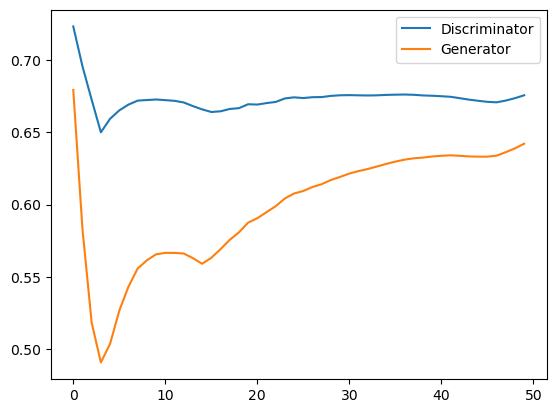

In [11]:
# Visualize Loss
plt.plot(loss_d, label='Discriminator')
plt.plot(loss_g, label='Generator')
plt.legend()
plt.show()

#### 8. Discriminator Evaluation

The `model.eval()` method is called on both the Discriminator and Generator models.
This sets the models to evaluation mode, disabling behavior like dropout and batch normalization updates that are only needed during training.

We iterate the test set and compute:

   `real_acc` computes the accuracy of the Discriminator in classifying real images by dividing the correct real classifications by the total number of real images.
*   `generated_acc` computes the accuracy of the Discriminator in classifying generated images in the same way.
*   `overall_acc` computes the overall accuracy by combining the correct classifications of both real and generated images.


In [ ]:
# Set to evaluation mode
discriminator.eval()
generator.eval()

real_correct = 0
generated_correct = 0
total_size = 0

all_probabilities_real = []
all_probabilities_generated = []

with torch.no_grad():
    for real_images, class_labels in test_loader:
        class_labels = class_labels.to(device)
        batch_size = real_images.size(0)
        total_size += batch_size

        # Evaluate on real images, apply sigmoid to convert logit as probability
        real_logits = discriminator(real_images.to(device), class_labels)
        real_prob = torch.sigmoid(real_logits.cpu())
        # Count correct predictions;
        real_correct += (real_prob > 0.5).sum().item()
        # Store logits for real samples
        all_probabilities_real.append(real_prob)

        # Evaluate on generated images
        # Generate noise
        z = torch.randn(batch_size, 100,1,1)
        # Generate images
        generated_images = generator(z.to(device), class_labels)

        generated_logits = discriminator(generated_images, class_labels)
        generated_probe = torch.sigmoid(generated_logits.cpu())
        # Count correct predictions
        generated_correct += (generated_probe < 0.5).sum().item()
        # Store logits for real samples
        all_probabilities_generated.append(generated_probe)

# Compute accuracy
real_acc = real_correct / total_size * 100
generated_acc = generated_correct / total_size * 100
overall_acc = (real_acc + generated_acc) / 2

print(f"Discriminator Evaluation:")
print(f"  - Accuracy on Real Images: {real_acc:.2f}%")
print(f"  - Accuracy on Generated Images: {generated_acc:.2f}%")
print(f"  - Overall Accuracy: {overall_acc:.2f}%")

Discriminator Evaluation:
  - Accuracy on Real Images: 97.51%
  - Accuracy on Generated Images: 10.09%
  - Overall Accuracy: 53.80%


We also plot the probability distributions for both real and generated samples.

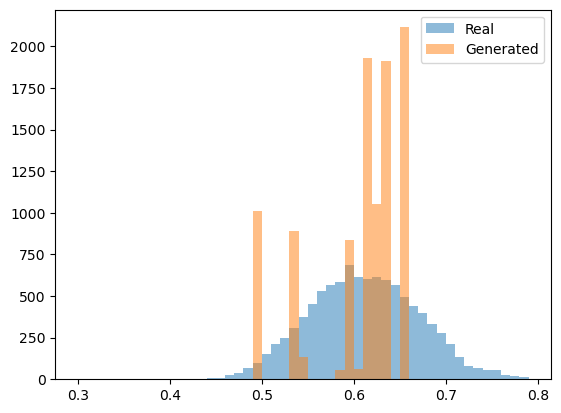

In [12]:
bins = torch.arange(0.3,0.8,0.01)
plt.hist(torch.cat(all_probabilities_real), bins=bins, label='Real', alpha=0.5)
plt.hist(torch.cat(all_probabilities_generated), bins=bins, label='Generated', alpha=0.5)
plt.legend()
plt.show()

#### 9. Visualizing Generator Output

We visualize:

1. How the trained Generator perform on random noise.
2. How the generated images from fixed noise evolve during training.

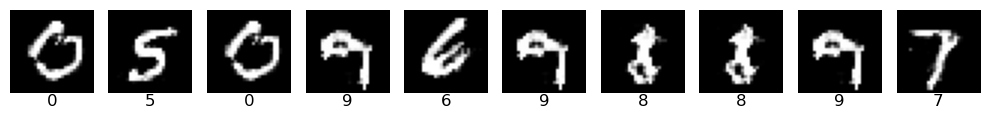

In [13]:
# we generate 10 images with randomly-assigned labels
z = torch.randn(10, 100, 1, 1, device=device)
generated_label = torch.randint(0, num_classes, (10,), device=device)
generated_images = generator(z.to(device), generated_label)
# show images with their target labels
show_images(generated_images, generated_label)

In [14]:
def show_generated_images(epoch):
    """
    This function is used to display the images generated by the **Generator** during training.
    It takes the epoch number as input, loads the corresponding generated images,
    rescales them to the proper range,
    and then displays the first 30 images from the batch.
    """
    # load saved images
    epoch_data = fixed_samples[epoch-1]
    # re-scale back to 0-1
    epoch_data = (epoch_data + 1) / 2
    # re-shape to (batch_size, channel, height, width)
    batch_size, channel, height, width = len(epoch_data), 1, 28, 28
    image_batch = epoch_data.view(batch_size, channel, height, width)
    show_images(image_batch[:30], fixed_labels[:30])


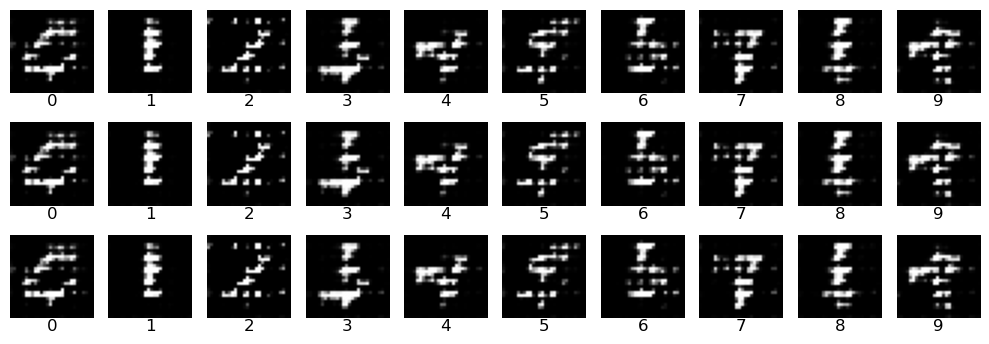

In [15]:
show_generated_images(epoch=1)

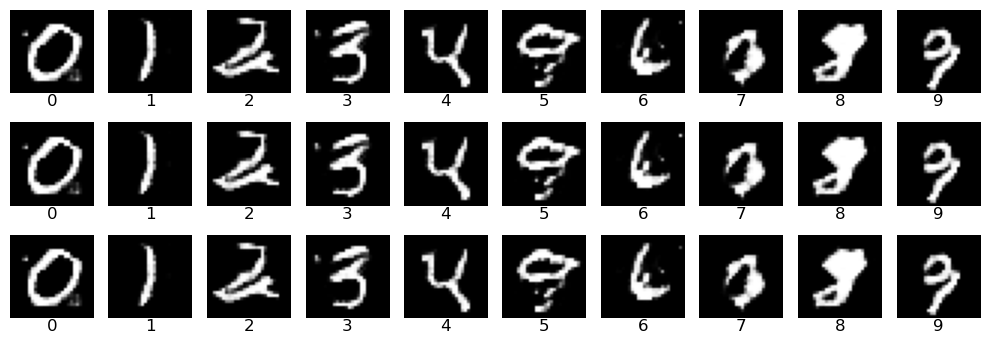

In [16]:
show_generated_images(epoch=15)

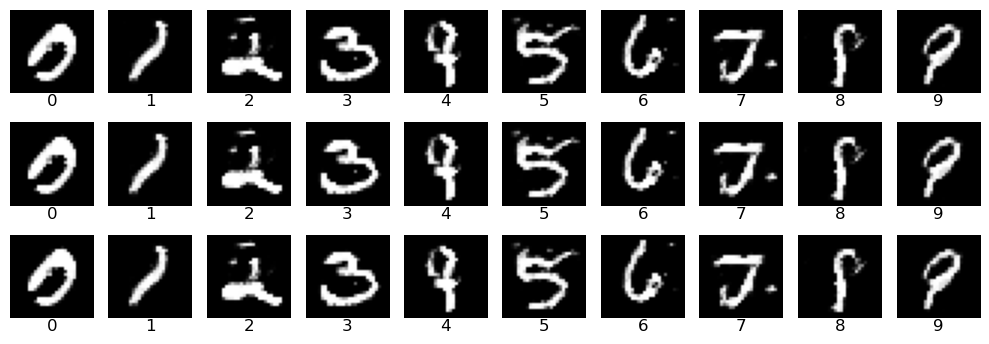

In [17]:
show_generated_images(epoch=25)

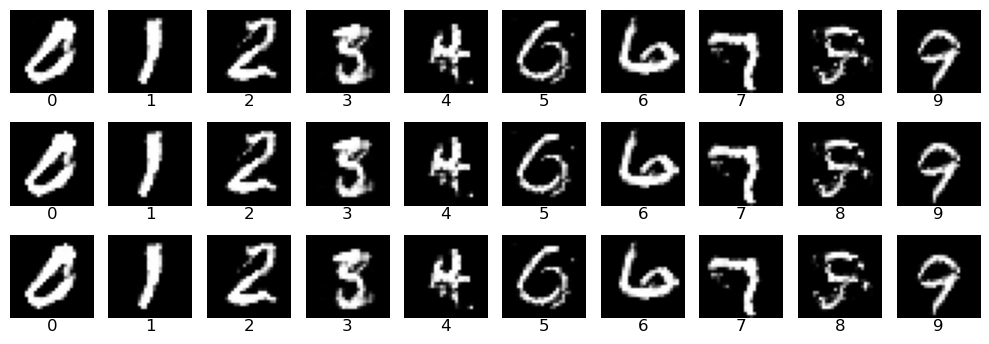

In [18]:
show_generated_images(epoch=35)

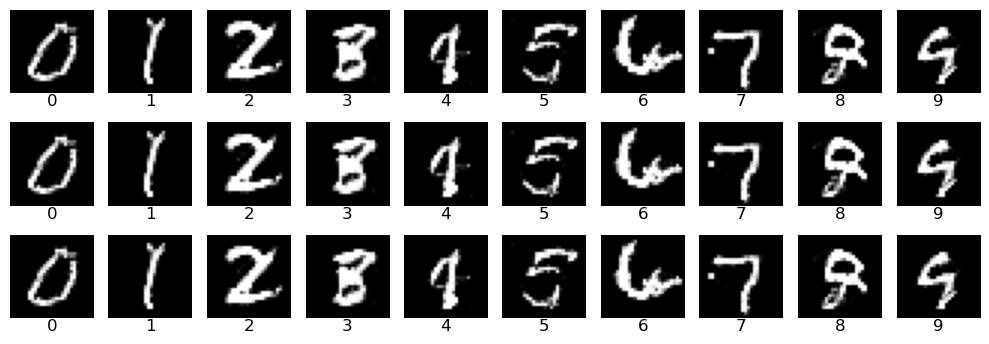

In [19]:
show_generated_images(epoch=40)

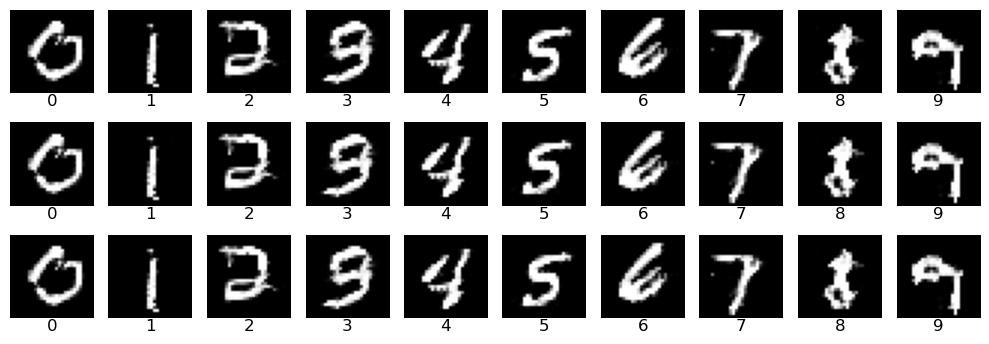

In [20]:
show_generated_images(epoch=50)

 ## Summary and Key Takeaways

 This notebook walked through the end-to-end implementation of a **Generative Adversarial Network (GAN)** / **Conditional GAN (cGAN)**, including all necessary components from data loading to training and image generation. Below is a summary of each section and some final insights.



 #### **Section 1: Imports and Setup**
 We loaded all necessary packages, including PyTorch for model construction and training, torchvision for working with the MNIST dataset, and `matplotlib` for visualization. We also configured the runtime device (CPU/GPU).



 #### **Section 2: Dataset Preparation**
 We downloaded and preprocessed the **MNIST** dataset. Images were normalized to the range [-1, 1] to match the Tanh output range of the Generator.



 #### **Section 3: Visualization Helpers**
 We defined helper functions like `show_images` to visualize generated samples. These are used periodically during training to monitor progress qualitatively.



 #### **Section 4: Generator Architecture**
 The **Generator** network transforms a latent vector (noise) into a realistic image through transposed convolutional layers and non-linearities. For cGANs, the noise vector is concatenated with label embeddings.

The Generator should progressively upscale the feature maps to reach the image resolution while preserving semantics via batch normalization and non-linearities.


 #### **Section 5: Discriminator Architecture**
 The **Discriminator** distinguishes real images from generated ones using convolutional layers. In the cGAN version, label information is incorporated into the input.

 The discriminator’s goal is to be a strong critic of image authenticity -- its feedback guides the Generator's learning.


 #### **Section 6: Optimizers and Losses**
 We used the **Adam optimizer** and the **Binary Cross-Entropy loss with logits (BCEWithLogitsLoss)**. Labels were carefully assigned: real = 1, generated = 0.


 #### **Section 7: Training the GAN**
 We iteratively trained both the Generator and Discriminator in a balanced way.
 Each epoch includes:
 - Updating the Discriminator using real and fake samples.
 - Updating the Generator using the Discriminator's feedback.
 - Visualizing outputs to track progress.


#### **Section 8: Evaluation and Visualization**
We evaluate the Discriminator by computing the accuracies for recognizing real and generated samples.
We visualize the performance of the Generator by plotting the generated images saved in different epochs.


 ---

 ### Final Takeaways
 - GANs learn by competition between a Generator and a Discriminator.
 - GAN training is a delicate balance. If one player becomes too strong too quickly, the model may collapse or fail to converge.
 - Stable training requires careful design of architecture, normalization, loss functions, and hyperparameters.
 - Conditional GANs enable class- or attribute-conditioned generation, providing greater output control.
 - Visual inspection during training is critical -- metrics alone do not capture all aspects of GAN performance. 
 - Proper analysis of the finally-produced samples is critical to detect issues of the trained GAN, such as the mode collapse we have seen in the cGAN example.